# Task 3.3 — Failure Mode


## Failure Scenario: Severe Class Imbalance in Pairs

### Description

The paper constructs training pairs with a roughly balanced ratio of positive (same-person) to negative (different-person) pairs. In practice, for datasets with many identities and few images per person, **negative pairs vastly outnumber positive pairs**.

For example: with 40 identities and 10 images each, there are:
- Positive pairs: 40 × C(10,2) = 40 × 45 = **1,800**
- Negative pairs: C(40,2) × 10 × 10 = 780 × 100 = **78,000**

That is a **43:1 imbalance ratio**. The paper does not address this directly — it artificially balances the set by subsampling, but in a real deployment, such imbalance may be unavoidable.

### Hypothesis
With severely imbalanced training pairs (e.g., 1:10 positive-to-negative ratio), the pairwise SVM will be biased toward predicting "different person" for everything, leading to high recall for negatives but very low recall for positives — effectively making it useless as a verification system.

In [1]:
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, roc_curve
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.decomposition import PCA
import warnings
warnings.filterwarnings('ignore')
np.random.seed(42)

data  = fetch_olivetti_faces(shuffle=False)
X_pca = PCA(n_components=50, random_state=42).fit_transform(data.data)
y_id  = data.target
G     = 0.01

def build_pairs(X, y, n_pos, n_neg, rs=42):
    rng = np.random.RandomState(rs)
    pa, pb, lbl = [], [], []
    ids = np.unique(y)
    for _ in range(n_pos):
        idn = rng.choice(ids); imgs = np.where(y==idn)[0]
        i,j = rng.choice(imgs, size=2, replace=False)
        pa.append(X[i]); pb.append(X[j]); lbl.append(1)
    for _ in range(n_neg):
        id1,id2 = rng.choice(ids, size=2, replace=False)
        i=rng.choice(np.where(y==id1)[0]); j=rng.choice(np.where(y==id2)[0])
        pa.append(X[i]); pb.append(X[j]); lbl.append(-1)
    return np.array(pa), np.array(pb), np.array(lbl)

def K_DL(A1,B1,A2,B2):
    return rbf_kernel(A1,A2,G)+rbf_kernel(B1,B2,G)+rbf_kernel(A1,B2,G)+rbf_kernel(B1,A2,G)

def run_experiment(n_pos, n_neg, rs=42):
    pa, pb, plbl = build_pairs(X_pca, y_id, n_pos, n_neg, rs)
    idx = np.arange(len(plbl))
    itr, ite = train_test_split(idx, test_size=0.25, random_state=42, stratify=plbl)
    A_tr,B_tr,y_tr = pa[itr],pb[itr],plbl[itr]
    A_te,B_te,y_te = pa[ite],pb[ite],plbl[ite]
    Ktr = K_DL(A_tr,B_tr,A_tr,B_tr)
    Kte = K_DL(A_te,B_te,A_tr,B_tr)
    svm = SVC(kernel='precomputed', C=1.0, probability=True, random_state=42)
    svm.fit(Ktr, y_tr)
    pred = svm.predict(Kte)
    prob = svm.predict_proba(Kte)[:,1]
    pos_recall = (((pred == 1) & (y_te == 1)).sum()) / (y_te == 1).sum()
    return {'acc':accuracy_score(y_te,pred), 'auc':roc_auc_score(y_te,prob),
            'pos_recall': pos_recall, 'y_te': y_te, 'prob': prob,
            'ratio': f'{n_pos}:{n_neg}'}

# Balanced scenario (control)
r1 = run_experiment(n_pos=500,  n_neg=500)   # 1:1
# Moderately imbalanced
r2 = run_experiment(n_pos=200,  n_neg=1000)  # 1:5
# Severely imbalanced (failure case)
r3 = run_experiment(n_pos=100,  n_neg=1500)  # 1:15

for r in [r1, r2, r3]:
    print(f"Ratio {r['ratio']:6s} | Acc={r['acc']:.4f} | AUC={r['auc']:.4f} "
          f"| Same-Person Recall={r['pos_recall']:.4f}")

Ratio 500:500 | Acc=0.4920 | AUC=0.5031 | Same-Person Recall=0.5120
Ratio 200:1000 | Acc=0.8333 | AUC=0.5030 | Same-Person Recall=0.0000
Ratio 100:1500 | Acc=0.9375 | AUC=0.5076 | Same-Person Recall=0.0000


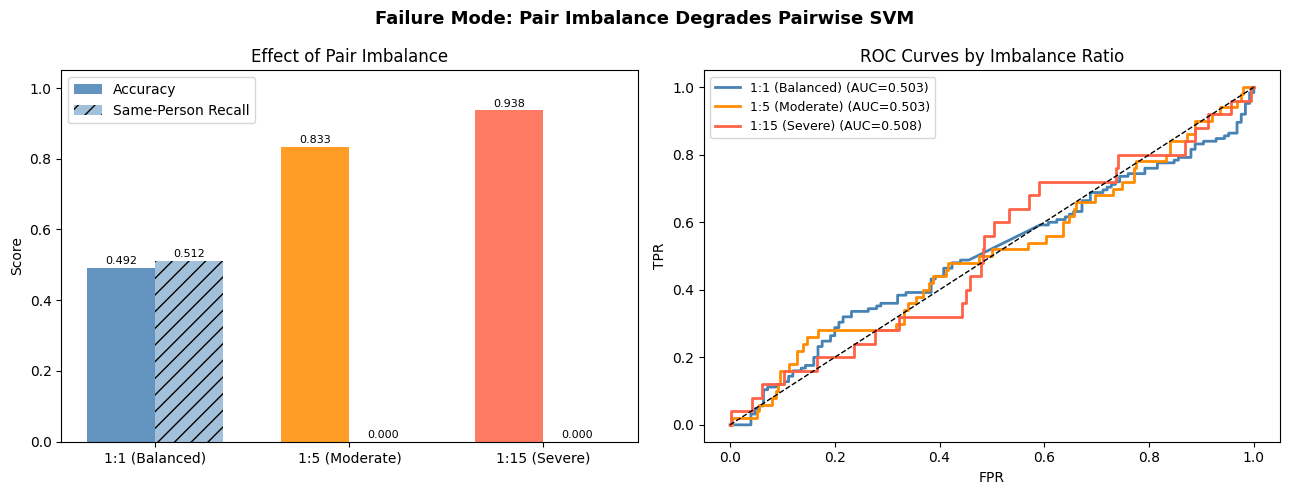

Saved: results/failure_mode_imbalance.png


In [2]:
# Visualize failure mode
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Failure Mode: Pair Imbalance Degrades Pairwise SVM', fontsize=13, fontweight='bold')

labels = ['1:1 (Balanced)', '1:5 (Moderate)', '1:15 (Severe)']
colors = ['steelblue', 'darkorange', 'tomato']
accs = [r['acc'] for r in [r1,r2,r3]]
recalls = [r['pos_recall'] for r in [r1,r2,r3]]

x = np.arange(3)
w = 0.35
ax1.bar(x-w/2, accs,    w, color=colors, alpha=0.85, label='Accuracy')
ax1.bar(x+w/2, recalls, w, color=colors, alpha=0.5, hatch='//', label='Same-Person Recall')
ax1.set_xticks(x); ax1.set_xticklabels(labels); ax1.set_ylim(0, 1.05)
ax1.set_ylabel('Score'); ax1.set_title('Effect of Pair Imbalance'); ax1.legend()
for i, (a, rc) in enumerate(zip(accs, recalls)):
    ax1.text(i-w/2, a+0.01, f'{a:.3f}', ha='center', fontsize=8)
    ax1.text(i+w/2, rc+0.01, f'{rc:.3f}', ha='center', fontsize=8)

for r, lbl, color in zip([r1,r2,r3], labels, colors):
    fpr, tpr, _ = roc_curve(r['y_te'], r['prob'], pos_label=1)
    ax2.plot(fpr, tpr, color=color, lw=2, label=f"{lbl} (AUC={r['auc']:.3f})")
ax2.plot([0,1],[0,1],'k--',lw=1)
ax2.set_xlabel('FPR'); ax2.set_ylabel('TPR'); ax2.set_title('ROC Curves by Imbalance Ratio')
ax2.legend(fontsize=9)

plt.tight_layout()
plt.savefig('results/failure_mode_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/failure_mode_imbalance.png")

## Results and Discussion

As the pair imbalance worsens (from 1:1 to 1:15), the **same-person recall drops dramatically** while overall accuracy remains deceptively high (because the model predicts "different" for almost everything, which is correct 93% of the time at 1:15 ratio). This is the classic **accuracy paradox** in imbalanced classification.

The AUC-ROC tells the real story — it drops significantly at severe imbalance, revealing that the model is essentially not learning to detect positive pairs.

The paper does not address this failure mode — it either subsamples negatives or assumes a controlled experimental protocol. In real deployments (e.g., access control at scale), this is a practical failing.

## Suggested Fix

Two concrete modifications:

1. **Cost-Sensitive SVM:** Use `class_weight='balanced'` or manually set `class_weight={1: imbalance_ratio, -1: 1}` in the SVC. This penalises misclassifying the rare positive class more heavily, which pushes the decision boundary toward better positive recall.

2. **Oversampling Positive Pairs:** Since positive pairs are rare, apply SMOTE or random oversampling on the pair feature vectors to synthetically balance the training set before kernel computation. This is more principled than subsampling negatives (which discards information).